In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import missingno as msno

pd.set_option("display.max_columns", None)
pd.options.display.float_format = '{:,.2f}'.format


In [2]:
building_consumption = pd.read_csv("/Users/maximebarbier/Documents/00 - Repositories/building-energy-Seattle/data/external/2016_Building_Energy_Benchmarking.csv")

In [3]:
# On regarde comment un batiment est défini dans ce jeu de données 
building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [4]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type 
building_consumption.info()

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   str    
 3   PrimaryPropertyType              3376 non-null   str    
 4   PropertyName                     3376 non-null   str    
 5   Address                          3376 non-null   str    
 6   City                             3376 non-null   str    
 7   State                            3376 non-null   str    
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   str    
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   str    
 12  Latitude                       

# 1 - ANALYSE EXPLORATOIRE 

A réaliser : 
- Une analyse descriptive des données, y compris une explication du sens des colonnes gardées, des arguments derrière la suppression de lignes ou de colonnes, des statistiques descriptives et des visualisations pertinentes.

Qelques pistes d'analyse : 

* Identifier les colonnes avec une majorité de valeurs manquantes ou constantes en utilisant la méthode value_counts() de Pandas
* Mettre en evidence les différences entre les immeubles mono et multi-usages
* Utiliser des pairplots et des boxplots pour faire ressortir les outliers ou des batiments avec des valeurs peu cohérentes d'un point de vue métier 

Pour vous inspirer, ou comprendre l'esprit recherché dans une analyse exploratoire, vous pouvez consulter ce notebook en ligne : https://www.kaggle.com/code/pmarcelino/comprehensive-data-exploration-with-python. Il ne s'agit pas d'un modèle à suivre à la lettre ni d'un template d'analyses attendues pour ce projet. 

## Nettoyage des données

In [6]:
df.shape

(3376, 46)

### Valeurs nulles

In [7]:
df.isna().mean().sort_values(ascending=False)

Comments                           1.000000
Outlier                            0.990521
YearsENERGYSTARCertified           0.964751
ThirdLargestPropertyUseType        0.823460
ThirdLargestPropertyUseTypeGFA     0.823460
SecondLargestPropertyUseType       0.502666
SecondLargestPropertyUseTypeGFA    0.502666
ENERGYSTARScore                    0.249704
LargestPropertyUseTypeGFA          0.005924
LargestPropertyUseType             0.005924
ZipCode                            0.004739
ListOfAllPropertyUseTypes          0.002666
Electricity(kWh)                   0.002666
SourceEUIWN(kBtu/sf)               0.002666
GHGEmissionsIntensity              0.002666
TotalGHGEmissions                  0.002666
NaturalGas(therms)                 0.002666
SteamUse(kBtu)                     0.002666
NaturalGas(kBtu)                   0.002666
SourceEUI(kBtu/sf)                 0.002666
Electricity(kBtu)                  0.002666
NumberofBuildings                  0.002370
SiteEUI(kBtu/sf)                

In [12]:
df[df["Outlier"].notna()]["Outlier"].value_counts()
# la colonne outliers a beaucoup de valeur vide mais elle a toutefois son utilité. Je vais la garder pour le moment.

Outlier
Low outlier     23
High outlier     9
Name: count, dtype: int64

In [16]:
df[df["Outlier"] == "High outlier"]

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
226,350,2016,NonResidential,Large Office,Second And Spring Building,1100 Second Avenue,Seattle,WA,"98,101.00",0942000045,7,DOWNTOWN,47.61,-122.34,1958,1.00,6,172842,25920,146922,"Data Center, Office, Parking",Office,"99,890.00",Data Center,"39,336.00",Parking,"25,000.00",NaN,NaN,297.40,299.20,909.60,911.50,"41,399,504.00","41,650,404.00",0.00,"11,663,150.00","39,794,668.00","16,048.31","1,604,831.00",False,NaN,Non-Compliant,High outlier,362.66,2.10
517,704,2016,NonResidential,Large Office,401 Elliott Ave West,401 Elliot Ave West,Seattle,WA,"98,119.00",7666202110,7,MAGNOLIA / QUEEN ANNE,47.62,-122.36,2000,1.00,4,129551,42500,87051,"Data Center, Office, Parking",Office,"82,273.00",Parking,"42,500.00",Data Center,"4,778.00",NaN,1.00,311.70,311.70,978.90,978.90,"27,137,190.00","27,137,190.00",0.00,"7,953,454.50","27,137,187.00",0.00,0.00,False,NaN,Non-Compliant,High outlier,189.18,1.46
1707,23174,2016,Multifamily LR (1-4),Mid-Rise Multifamily,Taylor Anne Condominium,1730 Taylor Ave N,Seattle,WA,"98,109.00",8567250000,7,MAGNOLIA / QUEEN ANNE,47.63,-122.35,1969,1.00,5,30569,0,30569,Multifamily Housing,Multifamily Housing,"30,921.00",NaN,NaN,NaN,NaN,NaN,1.00,221.00,231.90,684.30,717.20,"6,834,431.00","7,169,577.00",0.00,"1,961,077.75","6,691,197.00","1,432.33","143,233.00",False,NaN,Non-Compliant,High outlier,54.25,1.77
2763,26852,2016,Multifamily LR (1-4),Low-Rise Multifamily,Atlas Building,420 Maynard Avenue South,Seattle,WA,"98,104.00",5247802315,2,DOWNTOWN,47.60,-122.32,1920,1.00,4,46560,0,46560,"Multifamily Housing, Restaurant, Retail Store",Multifamily Housing,"46,560.00",Retail Store,"3,000.00",Restaurant,"2,000.00",NaN,NaN,133.50,134.10,211.30,213.50,"6,881,405.50","6,916,663.00",0.00,"514,840.69","1,756,636.00","51,247.69","5,124,769.00",False,NaN,Non-Compliant,High outlier,284.42,6.11
2863,27245,2016,Multifamily LR (1-4),Low-Rise Multifamily,St. Johns Apartments,725 E. Pike Street,Seattle,WA,"98,122.00",7502500061,3,EAST,47.61,-122.32,1910,1.00,3,24682,0,24682,"Multifamily Housing, Retail Store",Multifamily Housing,"17,822.00",Retail Store,"6,085.00",NaN,NaN,NaN,74.00,112.20,113.40,205.40,206.70,"2,681,771.00","2,710,595.00",0.00,"293,781.31","1,002,382.00","16,793.89","1,679,389.00",False,NaN,Non-Compliant,High outlier,96.18,3.90
2922,27526,2016,Multifamily LR (1-4),Low-Rise Multifamily,Vali Hai,800 1st Ave N.,Seattle,WA,"98,112.00",5457300300,7,MAGNOLIA / QUEEN ANNE,47.63,-122.36,1959,2.00,4,43346,0,43346,"Multifamily Housing, Parking, Swimming Pool",Multifamily Housing,"43,346.00",Parking,"12,600.00",Swimming Pool,0.00,NaN,5.00,104.30,111.90,205.60,216.10,"4,519,115.00","4,850,560.00",0.00,"584,334.69","1,993,750.00","25,253.65","2,525,365.00",False,NaN,Non-Compliant,High outlier,148.02,3.41
3082,28735,2016,Multifamily LR (1-4),Low-Rise Multifamily,Building 4,400 NE Thornton Place,Seattle,WA,"98,125.00",8632880000,5,NORTH,47.70,-122.32,2008,1.00,4,46725,0,46725,Multifamily Housing,Multifamily Housing,"102,522.00",NaN,NaN,NaN,NaN,NaN,1.00,131.30,140.10,218.60,230.90,"13,459,221.00","14,360,223.00",0.00,"1,161,542.75","3,963,184.00","94,960.36","9,496,036.00",False,NaN,Non-Compliant,High outlier,531.96,11.38
3092,29390,2016,Multifa

In [14]:
df.drop(columns=["Outlier","Comments"],inplace=True)

<Axes: >

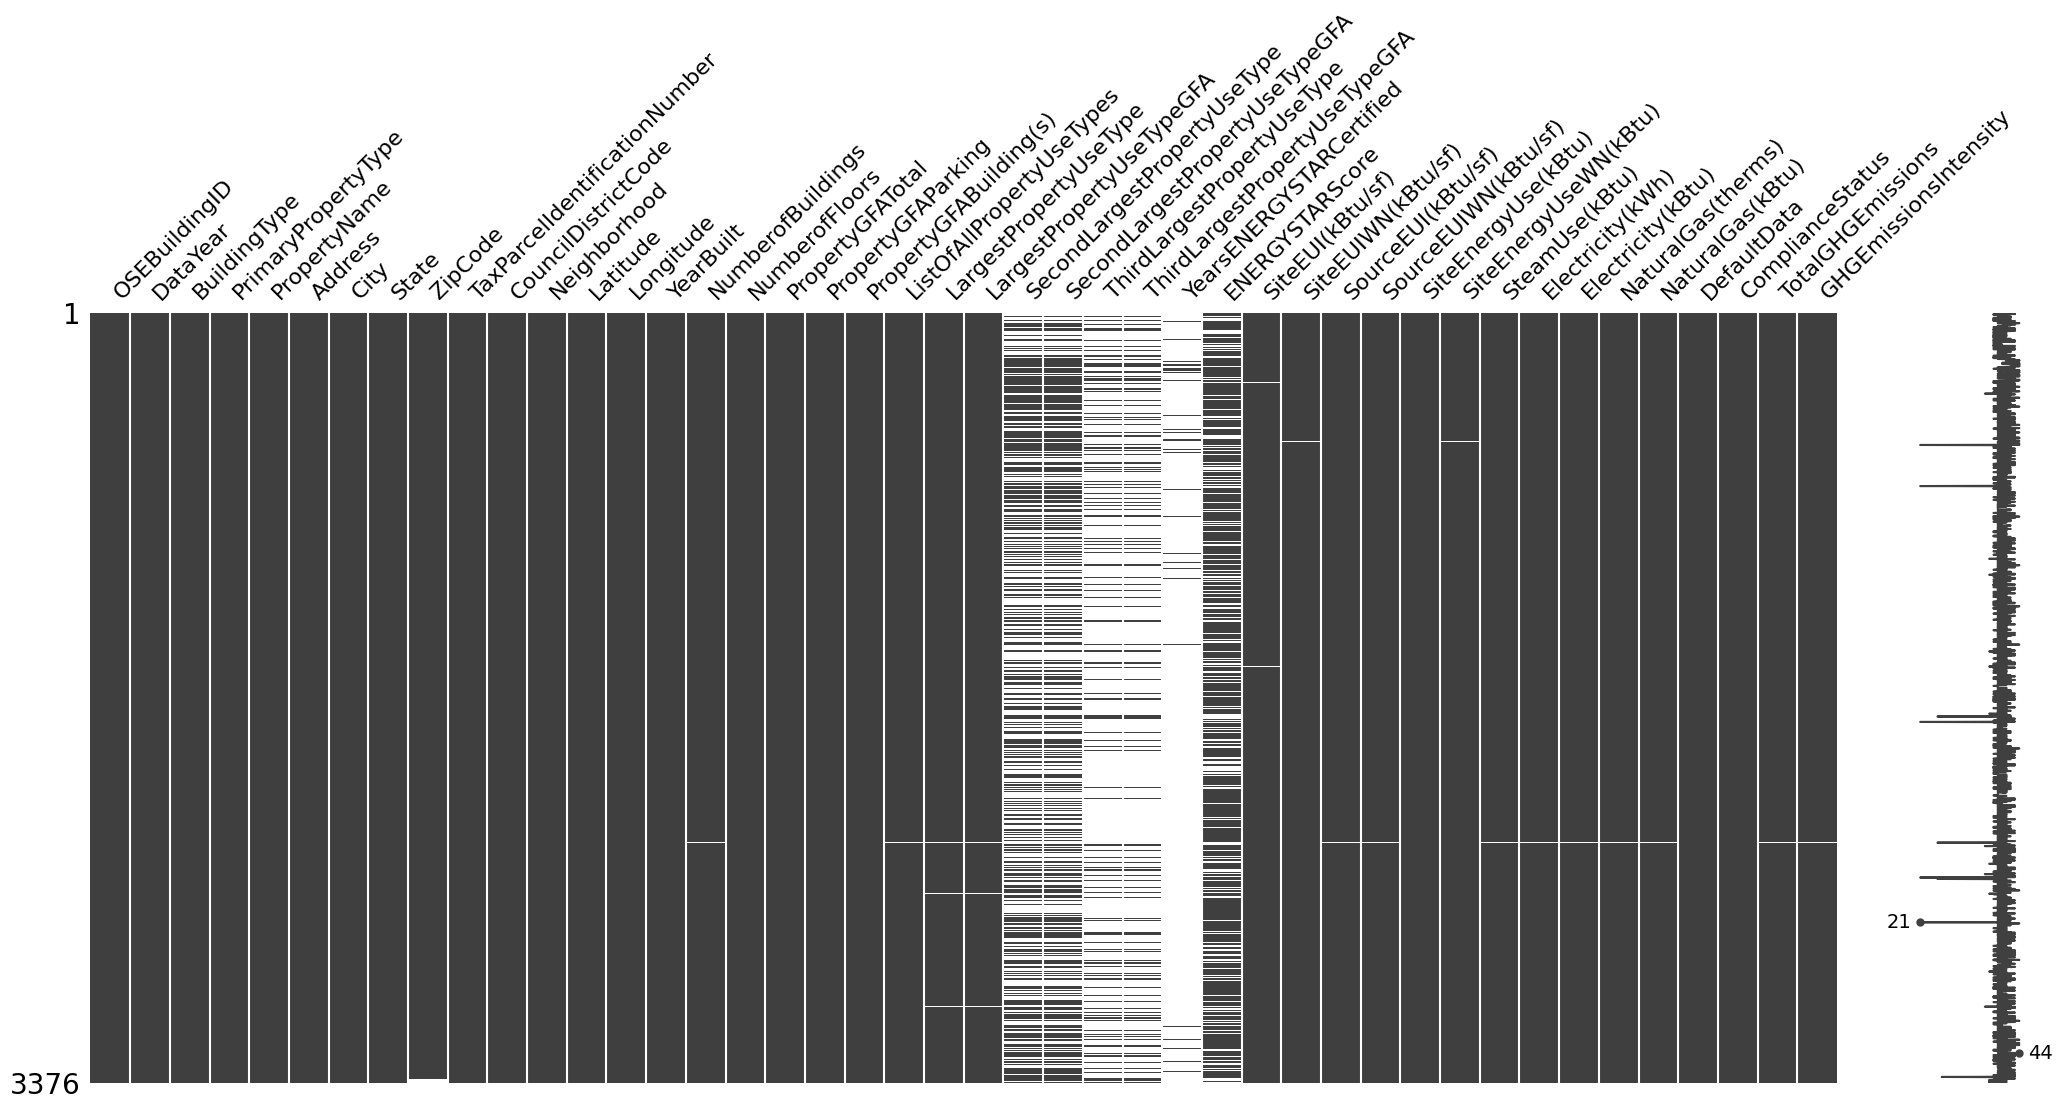

In [15]:
msno.matrix(df)

<Axes: >

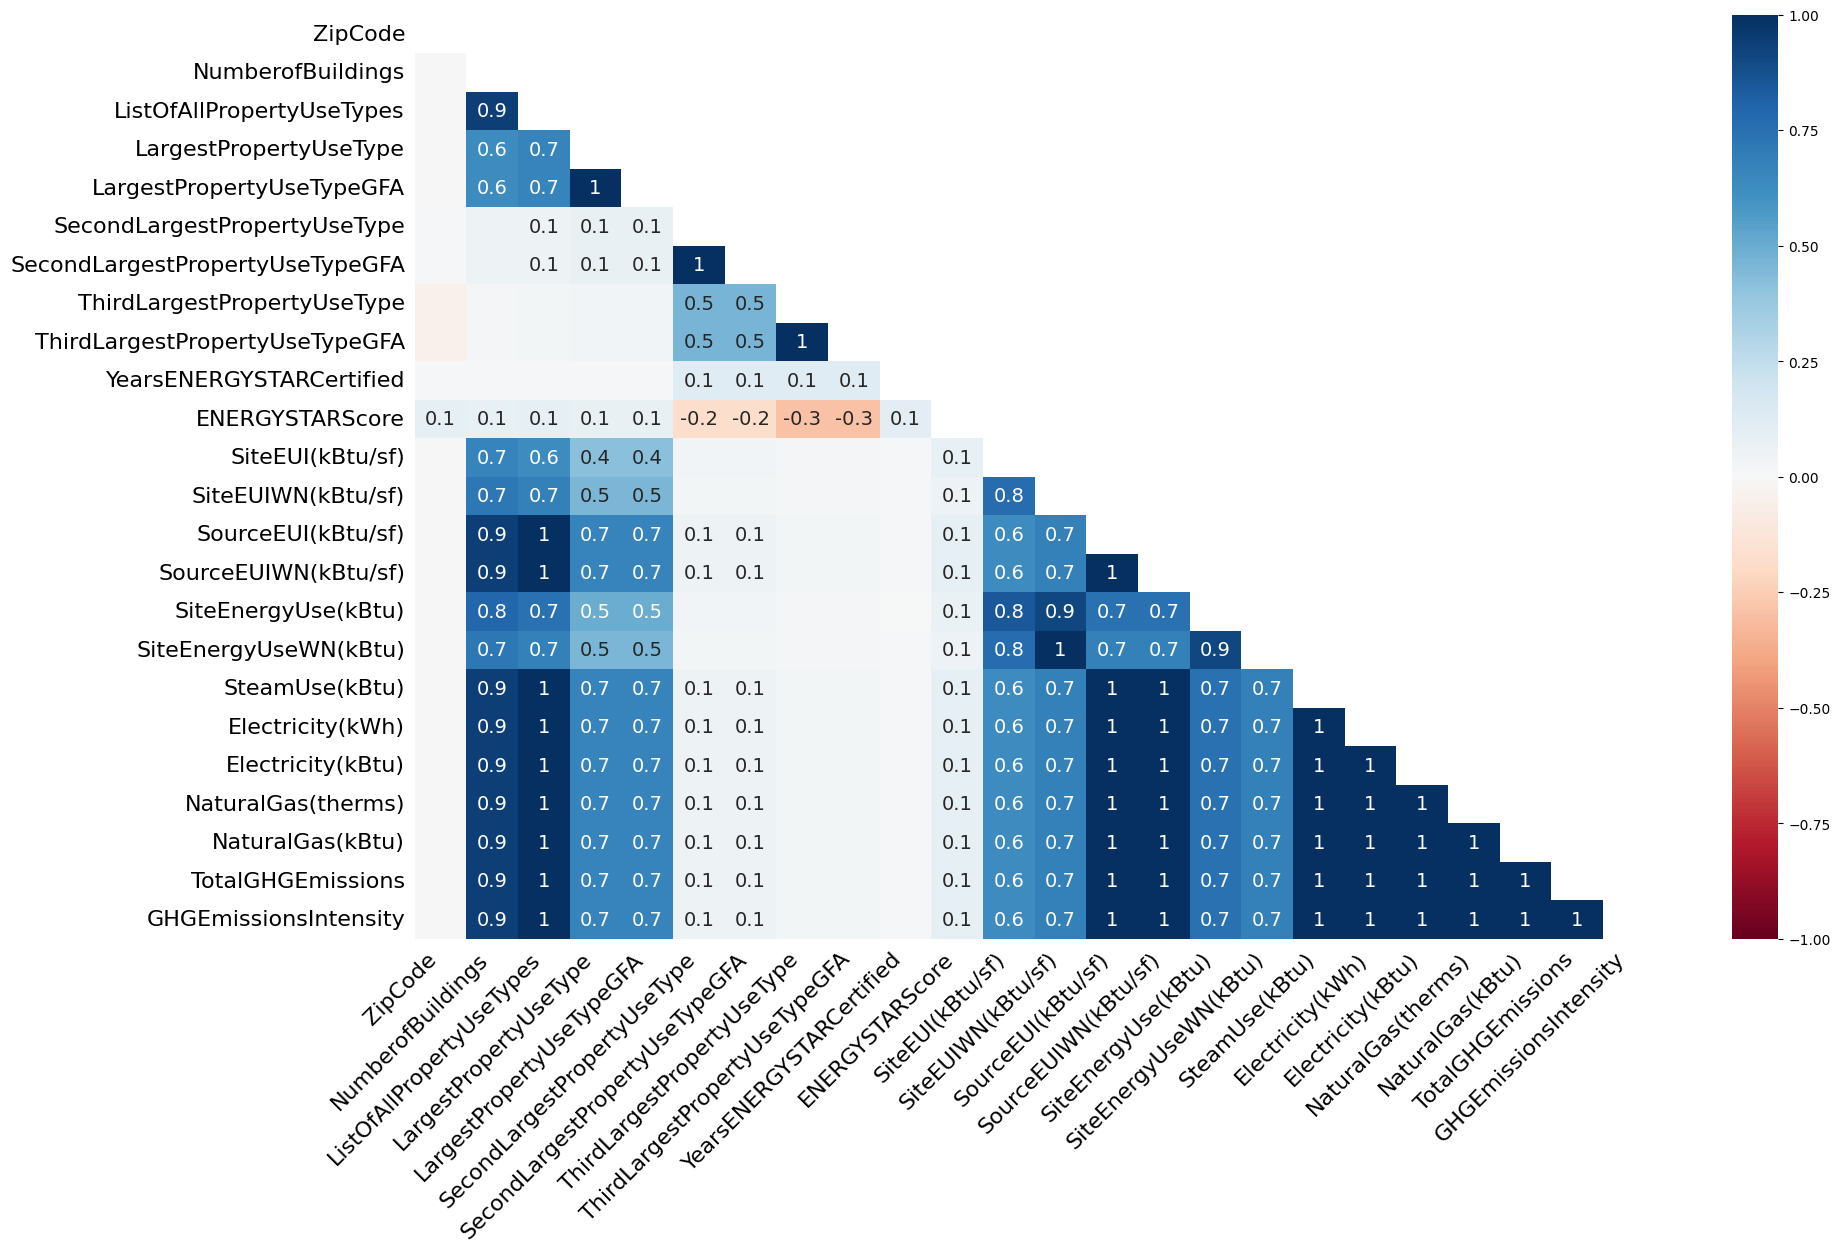

In [17]:
msno.heatmap(df)

<Axes: >

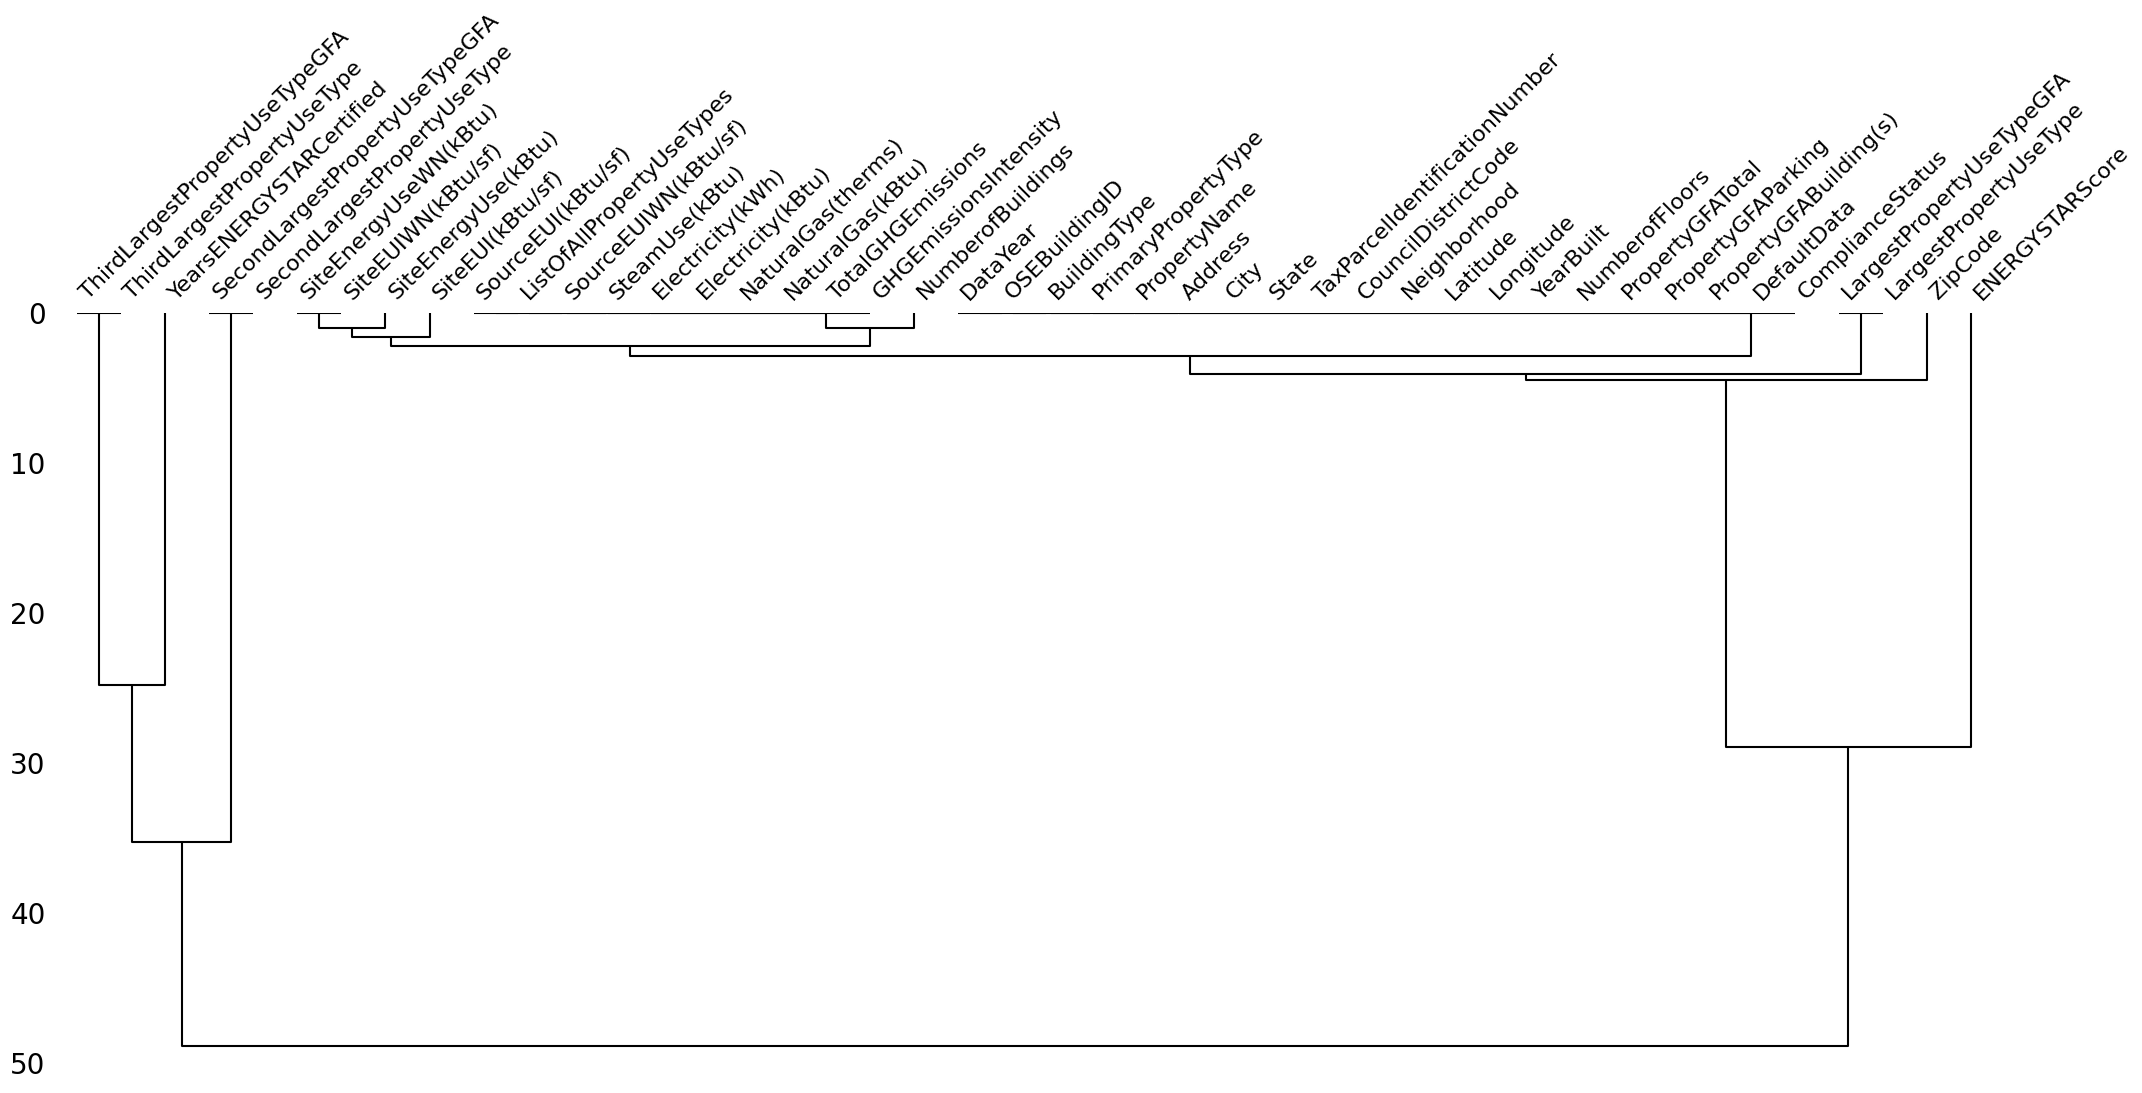

In [18]:
msno.dendrogram(df)

### Supprimer les doublons 👥 

In [20]:
df.duplicated().sum()

np.int64(0)

## Analyse univbariée

In [23]:
df.sample(5)

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
3259,49924,2016,NonResidential,Small- and Mid-Sized Office,SCCC DISTRICT/ERICKSON,1500 HARVARD AVE,Seattle,WA,98122.0,7502500010,...,2332889.25,0.0,5.805297e+05,1980767.0,2935.290039,293529.0,False,Compliant,29.40,0.45
1655,23010,2016,Multifamily MR (5-9),Mid-Rise Multifamily,Cedarvale House,11050 8th Ave NE,Seattle,WA,98125.0,2926049178,...,3858607.00,0.0,8.117775e+05,2769785.0,8311.119141,831112.0,False,Compliant,63.45,0.72
1569,22509,2016,NonResidential,Small- and Mid-Sized Office,Salmon Bay Landing,2320 W Commodore Way,Seattle,WA,98199.0,2771605313,...,1294615.25,0.0,3.794300e+05,1294615.0,0.000000,0.0,False,Compliant,9.03,0.22
1606,22801,2016,Nonresidential COS,Other,Meadowbrook Community Center/Pool,10700 30th Ave NE,Seattle,WA,98125.0,2826049024,...,8571176.00,0.0,7.645317e+05,2608582.0,54783.605470,5478361.0,False,Compliant,309.14,10.57
361,513,2016,NonResidential,Other,Q13 FOX,1813 Westlake Ave N,Seattle,WA,98109.0,1925049022,...,6876439.50,0.0,2.015369e+06,6876438.0,0.000000,0.0,False,Compliant,47.94,0.72


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 44 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   str    
 3   PrimaryPropertyType              3376 non-null   str    
 4   PropertyName                     3376 non-null   str    
 5   Address                          3376 non-null   str    
 6   City                             3376 non-null   str    
 7   State                            3376 non-null   str    
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   str    
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   str    
 12  Latitude                       

# Modélisation 

### Import des modules 

In [ ]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


### Feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes. 

En règle générale : On utilise la méthode .apply() de Pandas pour créer une nouvelle colonne à partir d'une colonne existante. N'hésitez pas à regarder les exemples dans les chapitres de cours donnés en ressource

In [ ]:
# CODE FEATURE ENGINEERING

### Préparation des features pour la modélisation

A réaliser :
* Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.
* Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.
* Débarrassez-vous des features redondantes en utilisant une matrice de corrélation de Pearson. Pour cela, utiisez la méthode corr() de Pandas, couplé d'un graphique Heatmap de la librairie Seaborn 
* Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).
*  Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).
* Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne. Les deux méthodes d'encodage à connaitre sont le OneHotEncoder et le LabelEncoder

In [ ]:
# CODE PREPARATION DES FEATURES

### Comparaison de différents modèles supervisés

A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

In [1]:
# CODE COMPARAISON DES MODELES

### Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn.

In [ ]:
# CODE OPTIMISATION ET INTERPRETATION DU MODELE